In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib as mpl
from scipy.stats import binned_statistic
import matplotlib.gridspec as gridspec

plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
# =================================================================
# 1. SETUP & LOADING
# =================================================================
BASE_DIR = '/home/storgaard/OneDrive/Speciale/Halofit/C_256+2048' 


def load_sim_folder(folder_path):
    """Loads all z-files in a folder into a dictionary: data[z_val] = (k, Ck)"""
    files = glob.glob(os.path.join(folder_path, "Ck_z*.txt"))
    data_dict = {}
    for f in files:
        match = re.search(r'Ck_z([\d\.]+)\.txt', os.path.basename(f))
        if match:
            z_val = round(float(match.group(1)), 2)
            data = np.loadtxt(f, skiprows=1)
            data_dict[z_val] = (data[:, 0], data[:, 1])
    return data_dict

print("Loading baseline...")
base_data = load_sim_folder(os.path.join(BASE_DIR, "baseline")) 

var_data = {'dNeff': {}, 'fidm': {}}
for folder_name in os.listdir(BASE_DIR):
    if folder_name == "baseline": continue
        
    match = re.match(r'(dNeff|fidm)_([+-]?[\d\.]+)', folder_name)
    if not match: continue
        
    param_name = match.group(1)
    delta_val = float(match.group(2))
    
    print(f"Loading {param_name} = {delta_val}...")
    var_data[param_name][delta_val] = load_sim_folder(os.path.join(BASE_DIR, folder_name))

Loading baseline...
Loading dNeff = 0.5...
Loading dNeff = 1.0...
Loading dNeff = 1.5...
Loading dNeff = 2.0...
Loading dNeff = -0.5...
Loading dNeff = -1.0...
Loading dNeff = -1.5...
Loading dNeff = -2.0...
Loading fidm = 0.5...
Loading fidm = 1.0...
Loading fidm = 1.5...
Loading fidm = 2.0...
Loading fidm = -0.5...
Loading fidm = -1.0...
Loading fidm = -1.5...
Loading fidm = -2.0...


In [3]:
# =================================================================
# 2. LOG-BINNING AND CALCULATING RESPONSE FUNCTIONS
# =================================================================
delta_x = 256 / 512 
k_nyquist = np.pi / delta_x
k_cut = 0.75 * k_nyquist
n_log_bins = 25

print(f"Nyquist frequency: {k_nyquist:.3f} 1/Mpc. Hard cutting data at: {k_cut:.3f} 1/Mpc.")

response_functions = {'dNeff': {}, 'fidm': {}} 

# --- NEW: Dictionaries to store the binned data so we NEVER bin twice ---
binned_base = {} 
binned_var = {'dNeff': {}, 'fidm': {}}

for param in ['dNeff', 'fidm']:
    delta_vals = np.array(list(var_data[param].keys()))
    if len(delta_vals) == 0: continue
        
    for z in base_data.keys():
        k_raw, Ck_base_raw = base_data[z]
        
        valid_mask = k_raw <= k_cut
        k_valid = k_raw[valid_mask]
        Ck_base_valid = Ck_base_raw[valid_mask]
        
        bins = np.logspace(np.log10(k_valid.min()), np.log10(k_valid.max()), n_log_bins + 1)
        
        k_binned, _, _  = binned_statistic(k_valid, k_valid, statistic='mean', bins=bins)
        Ck_base_binned, _, _ = binned_statistic(k_valid, Ck_base_valid, statistic='mean', bins=bins)
        
        nan_mask = ~np.isnan(k_binned) & ~np.isnan(Ck_base_binned)
        k_binned = k_binned[nan_mask]
        Ck_base_binned = Ck_base_binned[nan_mask]
        
        # Save baseline to dictionary
        if z not in binned_base:
            binned_base[z] = (k_binned, Ck_base_binned)
        
        y_matrix = []
        valid_x = []
        
        for d_val in delta_vals:
            if z in var_data[param][d_val]:
                _, Ck_var_raw = var_data[param][d_val][z]
                Ck_var_valid = Ck_var_raw[valid_mask]
                
                Ck_var_binned, _, _ = binned_statistic(k_valid, Ck_var_valid, statistic='mean', bins=bins)
                Ck_var_binned = Ck_var_binned[nan_mask]
                
                # Save varied model to dictionary
                if d_val not in binned_var[param]:
                    binned_var[param][d_val] = {}
                binned_var[param][d_val][z] = (k_binned, Ck_var_binned)
                
                y_matrix.append(Ck_var_binned - Ck_base_binned)
                valid_x.append(d_val)
                
        y_matrix = np.array(y_matrix)
        valid_x = np.array(valid_x)
        
        if len(valid_x) > 0:
            numerator = np.dot(valid_x, y_matrix) 
            denominator = np.sum(valid_x**2)
            slope_array = numerator / denominator
            
            sigma_array = np.ones_like(k_binned)
            if param == 'fidm' and z > 0.3:
                emphasis_mask = k_binned > 1.5
                sigma_array[emphasis_mask] = 0.1
            
            response_functions[param][z] = (k_binned, slope_array, sigma_array)

print(f"\nResponse functions, weights, and binned arrays cached using {n_log_bins} log-bins!")

Nyquist frequency: 6.283 1/Mpc. Hard cutting data at: 4.712 1/Mpc.

Response functions, weights, and binned arrays cached using 25 log-bins!


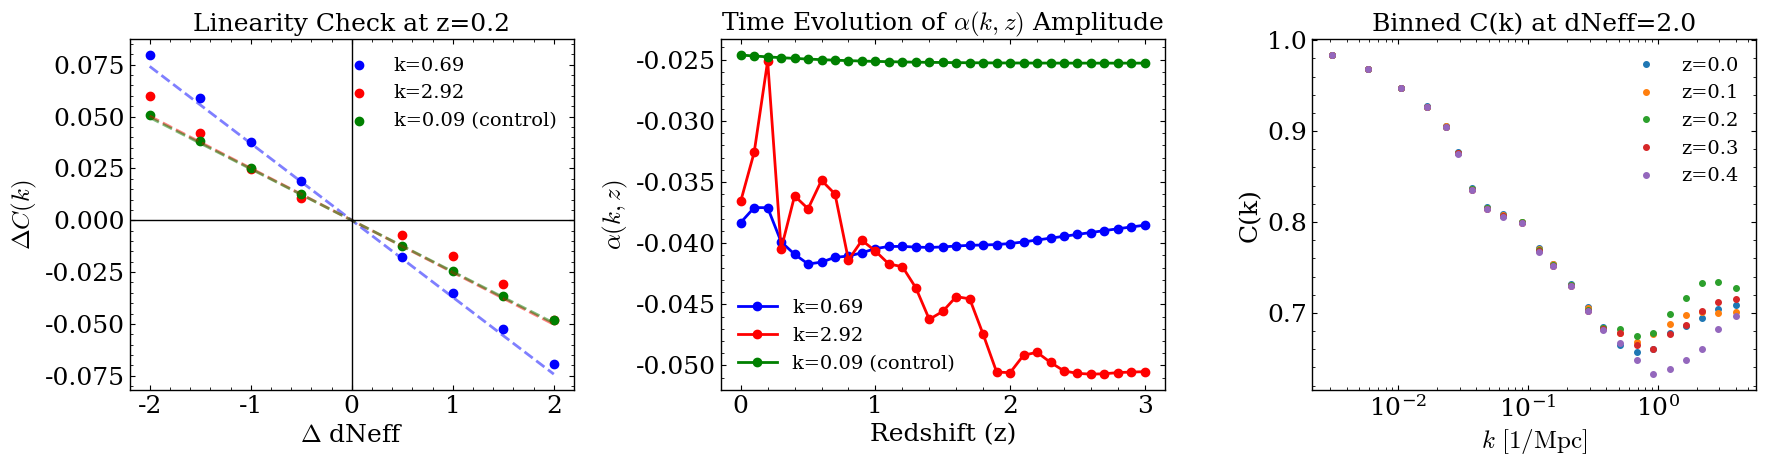

In [4]:
z_to_diagnose = [0.0, 0.1, 0.2, 0.3, 0.4]
plot_param = 'dNeff'  # Change to 'fidm' if you want to plot that response instead

# Find specific k-indices using the BINNED k-array from the cached baseline
k_binned_sample, _ = binned_base[0.0]
k_idx_1 = np.argmin(np.abs(k_binned_sample - 0.8)) # The main dip
k_idx_2 = np.argmin(np.abs(k_binned_sample - 3.0)) # The high-k rise
k_idx_3 = np.argmin(np.abs(k_binned_sample - 0.1)) # A control point in the linear regime

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =================================================================
# DIAGNOSTIC 1: Is the response actually linear?
# =================================================================
ax1 = axes[0]
test_z = 0.2  

x_vals = []
y_vals_dip1 = []
y_vals_dip2 = []
y_vals_control = []

# INSTANT FETCH: Grab the binned baseline
_, Ck_base_binned = binned_base[test_z]

for d_val in sorted(binned_var[plot_param].keys()):
    if test_z in binned_var[plot_param][d_val]:
        # INSTANT FETCH: Grab the binned variation
        _, Ck_var_binned = binned_var[plot_param][d_val][test_z]
        
        x_vals.append(d_val)
        y_vals_dip1.append(Ck_var_binned[k_idx_1] - Ck_base_binned[k_idx_1])
        y_vals_dip2.append(Ck_var_binned[k_idx_2] - Ck_base_binned[k_idx_2])
        y_vals_control.append(Ck_var_binned[k_idx_3] - Ck_base_binned[k_idx_3])

ax1.scatter(x_vals, y_vals_dip1, color='blue', label=f'k={k_binned_sample[k_idx_1]:.2f}')
ax1.scatter(x_vals, y_vals_dip2, color='red', label=f'k={k_binned_sample[k_idx_2]:.2f}')
ax1.scatter(x_vals, y_vals_control, color='green', label=f'k={k_binned_sample[k_idx_3]:.2f} (control)')

# Plot the calculated regression lines
slope1 = response_functions[plot_param][test_z][1][k_idx_1]
slope2 = response_functions[plot_param][test_z][1][k_idx_2]
slope3 = response_functions[plot_param][test_z][1][k_idx_3]

x_line = np.linspace(min(x_vals), max(x_vals), 10)
ax1.plot(x_line, slope1 * x_line, 'b--', alpha=0.5)
ax1.plot(x_line, slope2 * x_line, 'r--', alpha=0.5)
ax1.plot(x_line, slope3 * x_line, 'g--', alpha=0.5)

ax1.set_title(f'Linearity Check at z={test_z}')
ax1.set_xlabel(rf'$\Delta$ {plot_param}')
ax1.set_ylabel(r'$\Delta C(k)$')
ax1.axhline(0, color='k', lw=1)
ax1.axvline(0, color='k', lw=1)
ax1.legend()

# =================================================================
# DIAGNOSTIC 2: The Continuous Redshift Turnaround
# =================================================================
ax2 = axes[1]
all_z = sorted(list(response_functions[plot_param].keys()))
alpha_at_dip1 = [response_functions[plot_param][z][1][k_idx_1] for z in all_z]
alpha_at_dip2 = [response_functions[plot_param][z][1][k_idx_2] for z in all_z]
alpha_at_control = [response_functions[plot_param][z][1][k_idx_3] for z in all_z]

ax2.plot(all_z, alpha_at_dip1, 'b-o', label=f'k={k_binned_sample[k_idx_1]:.2f}')
ax2.plot(all_z, alpha_at_dip2, 'r-o', label=f'k={k_binned_sample[k_idx_2]:.2f}')
ax2.plot(all_z, alpha_at_control, 'g-o', label=f'k={k_binned_sample[k_idx_3]:.2f} (control)')

ax2.set_title(r'Time Evolution of $\alpha(k, z)$ Amplitude')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel(r'$\alpha(k, z)$')
ax2.legend()

# =================================================================
# DIAGNOSTIC 3: Raw Unsubtracted Binned Spectra
# =================================================================
ax3 = axes[2]
test_delta = max(binned_var[plot_param].keys())

for z in z_to_diagnose:
    if z in binned_var[plot_param][test_delta]:
        # INSTANT FETCH: Grab the binned variation for plotting
        k_var_binned, Ck_var_binned = binned_var[plot_param][test_delta][z]
        ax3.plot(k_var_binned, Ck_var_binned, label=f'z={z}', ls='None', marker='o', markersize=4)

ax3.set_xscale('log')
ax3.set_title(f'Binned C(k) at {plot_param}={test_delta}')
ax3.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax3.set_ylabel('C(k)')
ax3.legend()

plt.tight_layout()
plt.show()

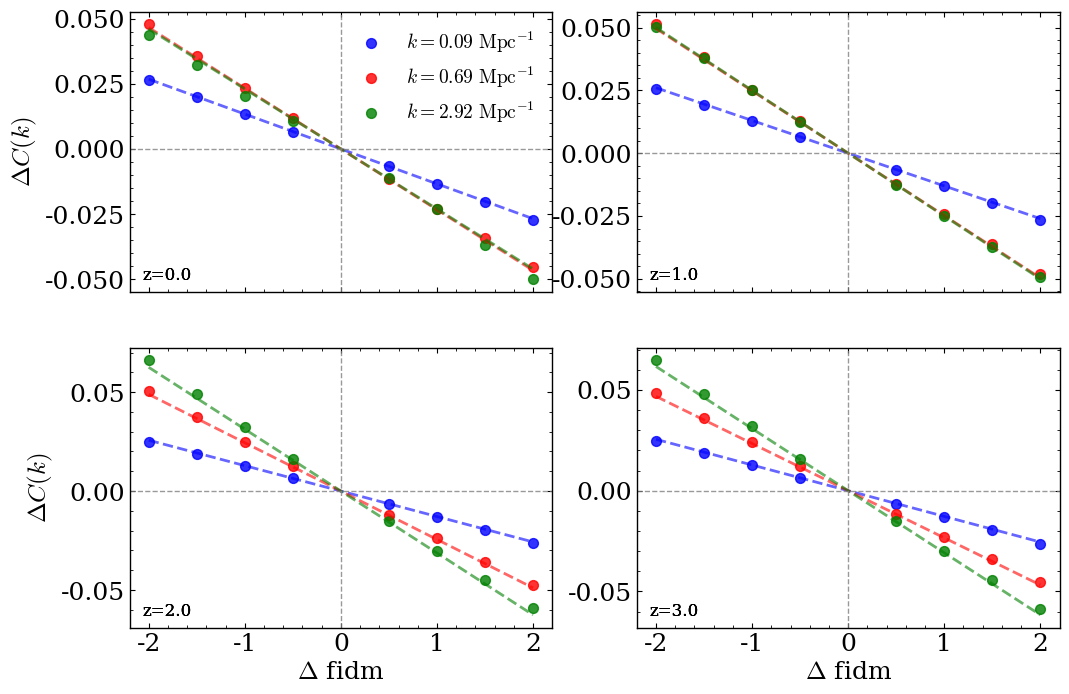

In [5]:
# Make a plot with only the linearity diagnostic but with all redshifts on the same plot to see the evolution of the linearity across redshift.
# =================================================================
# DIAGNOSTIC 1: Comprehensive Linearity Check (k and z dependence)
# =================================================================
plot_param = 'fidm'  # Parameter to check ('dNeff' or 'fidm')
z_to_show = [0.0, 1.0, 2.0, 3.0] # Pick 4 representative redshifts to form a 2x2 grid

# Find specific k-indices using the BINNED k-array from the cached baseline
k_binned_sample, _ = binned_base[0.0]
k_idx_1 = np.argmin(np.abs(k_binned_sample - 0.1)) # Control point in linear regime
k_idx_2 = np.argmin(np.abs(k_binned_sample - 0.8)) # The main dip
k_idx_3 = np.argmin(np.abs(k_binned_sample - 3.0)) # The high-k rise


k_indices = [k_idx_1, k_idx_2, k_idx_3]
colors = ['blue', 'red', 'green']
k_labels = [
    rf'$k={k_binned_sample[k_idx_1]:.2f} \ \mathrm{{Mpc}}^{{-1}}$',
    rf'$k={k_binned_sample[k_idx_2]:.2f} \ \mathrm{{Mpc}}^{{-1}}$',
    rf'$k={k_binned_sample[k_idx_3]:.2f} \ \mathrm{{Mpc}}^{{-1}}$'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, test_z in enumerate(z_to_show):
    ax = axes[i]
    
    # Skip if the selected redshift isn't in our loaded data
    if test_z not in binned_base:
        ax.set_title(f'No data for z={test_z}')
        continue
        
    _, Ck_base_binned = binned_base[test_z]
    
    # Dictionaries to hold data for the scatter plot
    x_vals = []
    y_vals = {idx: [] for idx in k_indices}
    
    # Extract the scattered data
    for d_val in sorted(binned_var[plot_param].keys()):
        if test_z in binned_var[plot_param][d_val]:
            _, Ck_var_binned = binned_var[plot_param][d_val][test_z]
            x_vals.append(d_val)
            for idx in k_indices:
                y_vals[idx].append(Ck_var_binned[idx] - Ck_base_binned[idx])
                
    # Plot Scatter and Regression Lines for each k-index
    for c_idx, k_idx in enumerate(k_indices):
        # 1. Scatter the actual simulation points
        ax.scatter(x_vals, y_vals[k_idx], color=colors[c_idx], s=50, alpha=0.8, label=k_labels[c_idx] if i==0 else "")
        
        # 2. Plot the calculated regression slope
        slope = response_functions[plot_param][test_z][1][k_idx]
        x_line = np.linspace(min(x_vals), max(x_vals), 50)
        y_line = slope * x_line
        ax.plot(x_line, y_line, color=colors[c_idx], linestyle='--', alpha=0.6)
        # Insert legend for the first subplot only to avoid repetition
        if i == 0:
            ax.legend(loc='best',)
        # Insert text saying which z is being plotted
        ax.text(0.03, 0.09, f'z={test_z}', transform=ax.transAxes, verticalalignment='top', fontsize=12)

    # Formatting each subplot
    ax.axhline(0, color='grey', lw=1, alpha=0.8, ls = '--')
    ax.axvline(0, color='grey', lw=1, alpha=0.8, ls = '--')
    
    # Add axis labels only to the outer edges to keep it clean
    if i >= 2:
        ax.set_xlabel(rf'$\Delta$ {plot_param}')
    if i % 2 == 0:
        ax.set_ylabel(r'$\Delta C(k)$')
plt.show()

# Save the figure
# fig.savefig('linearity_check_fidm.pdf', dpi=300, bbox_inches='tight')

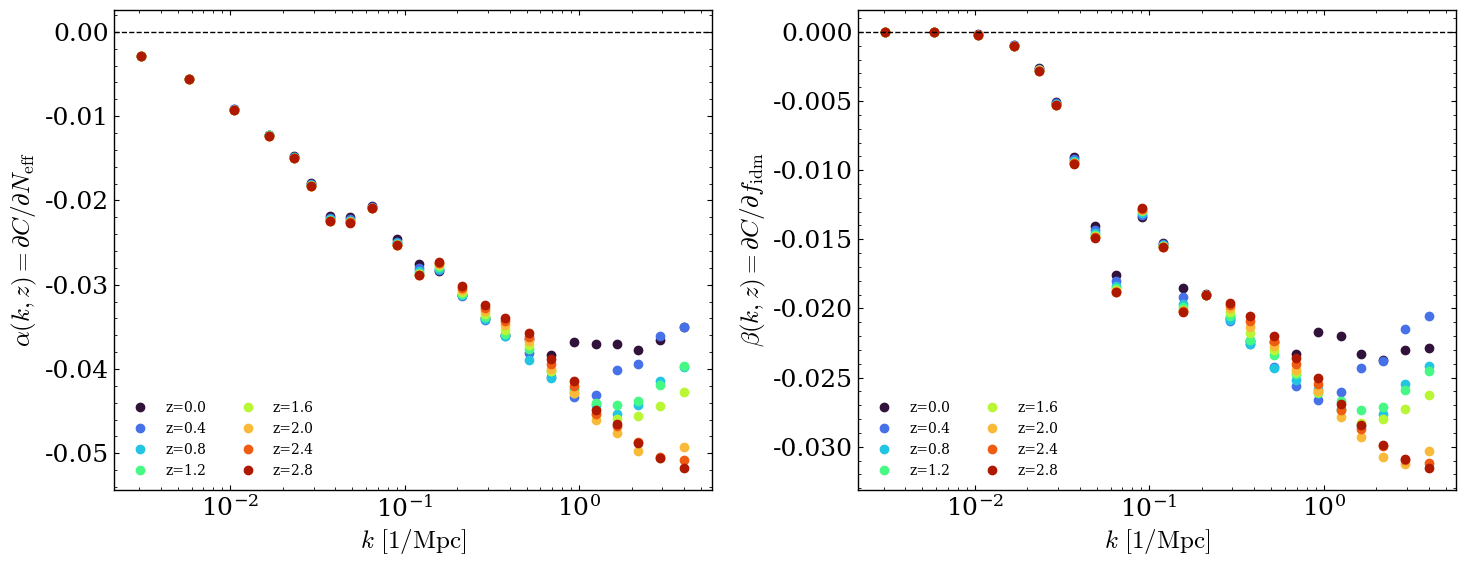

In [6]:
# =================================================================
# 3. PLOT THE RESPONSE FUNCTIONS
# =================================================================
z_to_plot = [0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8] # Choose a few representative redshifts to plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cmap = plt.get_cmap('turbo') 
z_min, z_max = 0.0, 3.0
norm = mpl.colors.Normalize(vmin=z_min, vmax=z_max)

# Plot alpha(k) for dNeff
if 'dNeff' in response_functions and response_functions['dNeff']:
    for z in z_to_plot:
        color = cmap(norm(z))
        if z in response_functions['dNeff']:
            # ---> NEW: Unpack the third 'sigma' item using '_' <---
            k, alpha, _ = response_functions['dNeff'][z]
            ax1.plot(k, alpha, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax1.set_xscale('log')
    ax1.axhline(0, color='black', lw=1, ls='--')
    ax1.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax1.set_ylabel(r'$\alpha(k, z) = \partial C / \partial N_{\mathrm{eff}}$')
    ax1.legend(loc='lower left', ncols=2, fontsize=10)


# Plot beta(k) for fidm
if 'fidm' in response_functions and response_functions['fidm']:
    for z in z_to_plot:
        if z in response_functions['fidm']:
            # ---> NEW: Unpack the third 'sigma' item using '_' <---
            k, beta, _ = response_functions['fidm'][z]
            color = cmap(norm(z))
            ax2.plot(k, beta, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax2.set_xscale('log')
    ax2.axhline(0, color='black', lw=1, ls='--')
    ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax2.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{idm}}$')
    ax2.legend(loc='lower left', ncols=2, fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# =================================================================
# 3. PADE APPROXIMANT MODEL DEFINITION & BOUNDS
# =================================================================
def pade_model(k, z, a1_0, a1_z, a2_0, a2_z, a3_0, a3_z, b1_0, b1_z, b2_0, b2_z, b3_0, b3_z):
    """
    3rd-Order Padé Approximant.
    Numerator and Denominator coefficients scale as (1+z)^p
    """
    u = 1.0 + z
    
    # Numerator coefficients
    a1 = a1_0 * (u ** a1_z)
    a2 = a2_0 * (u ** a2_z)
    a3 = a3_0 * (u ** a3_z)
    
    # Denominator coefficients
    b1 = b1_0 * (u ** b1_z)
    b2 = b2_0 * (u ** b2_z)
    b3 = b3_0 * (u ** b3_z)
    
    num = a1*k + a2*(k**2) + a3*(k**3)
    den = 1.0 + b1*k + b2*(k**2) + b3*(k**3)
    
    return num / den

def fit_wrapper(coords, *params):
    k, z = coords
    return pade_model(k, z, *params)

# -----------------------------------------------------------------
# Initial Guesses (p0) and Bounds
# -----------------------------------------------------------------
# We force the base coefficients (a_i_0, b_i_0) to be strictly positive (>0)
# This prevents the denominator from crossing zero (singularities/poles) for k > 0.
# The z-exponents can be negative or positive.

p0_guess = [
    # a1_0, a1_z, a2_0, a2_z, a3_0, a3_z
    1.0, 0.0, 1.0, 0.0, 0.8, 0.0,
    # b1_0, b1_z, b2_0, b2_z, b3_0, b3_z
    1.0, 0.0, 1.5, 0.0, 1.0, 0.0
]

# Lower bounds: Base coeffs > 0.001 to avoid poles. Exponents down to -10.
lower_bounds = [
    -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf,
      0.001, -np.inf,   0.001, -np.inf,   0.001, -np.inf
]

# Upper bounds: Give the optimizer plenty of room
upper_bounds = [
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10,
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10
]

bounds_pade = (lower_bounds, upper_bounds)

labels = ['a1_0', 'a1_z', 'a2_0', 'a2_z', 'a3_0', 'a3_z', 
          'b1_0', 'b1_z', 'b2_0', 'b2_z', 'b3_0', 'b3_z']

# =================================================================
# 4. EXECUTION (Weighted Fits)
# =================================================================
def perform_fit(k_arr, z_arr, Ck_arr, weights_arr, p0, bounds, regime_name):
    print(f"\n--- Fitting {regime_name} ---")
    try:
        sigma_arr = 1.0 / weights_arr
        
        popt, pcov = curve_fit(
            fit_wrapper, 
            (k_arr, z_arr), 
            Ck_arr, 
            p0=p0, 
            sigma=sigma_arr, 
            absolute_sigma=False,
            maxfev=500000, # Increased maxfev as Pade can take longer to converge
            bounds=bounds
        )

        for l, val in zip(labels, popt):
            print(f"  {l}: {val:>8.4f}")
            
        return popt, pcov
        
    except RuntimeError as e:
        print(f"Fit failed for {regime_name}:", e)
        return None, None

# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['dNeff'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)
sigma_all = np.concatenate(sigma_all)
# -----------------------------------------------------------------
# OPTION A: The Global Fit (Recommended to try first)
# -----------------------------------------------------------------
print("Attempting Global Fit...")
popt_global_dNeff, pcov_global_dNeff = perform_fit(
    k_all, z_all, resp_all, sigma_all, p0_guess, bounds_pade, "Global (All z)"
)

Attempting Global Fit...

--- Fitting Global (All z) ---
  a1_0:  -1.3584
  a1_z:   0.0003
  a2_0:  -1.8450
  a2_z:  -0.5134
  a3_0:  -5.3787
  a3_z:  -3.2322
  b1_0:  48.1846
  b1_z:  -0.0622
  b2_0:   5.7844
  b2_z:   0.2486
  b3_0: 179.0488
  b3_z:  -3.1151


In [8]:
# =================================================================
# 3. EXECUTION (WITH RANDOMIZED GLOBAL FIT LOOP)
# =================================================================
# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['dNeff'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)
sigma_all = np.concatenate(sigma_all)

# --- NEW: Randomized 100 Loop Execution ---
n_runs = 100
successful_fits_dNeff = []

print(f"Attempting {n_runs} randomized global fits for dNeff...")

for i in range(n_runs):
    # Generate random initial guesses (p0)
    # We want base coeffs (indices 0, 2, 4, 6, 8, 10) to be strictly positive.
    # We want z-exponents (indices 1, 3, 5, 7, 9, 11) to freely vary.
    p0_random = np.zeros(12)
    p0_random[0::2] = np.random.uniform(0.01, 500, size=6)  # Base coeffs
    p0_random[1::2] = np.random.uniform(-500, 500, size=6)   # z-exponents
    
    try:
        # Curve fit using the provided very loose bounds_pade
        popt, pcov = curve_fit(
            fit_wrapper, 
            (k_all, z_all), 
            resp_all, 
            p0=p0_random, 
            sigma=sigma_all, 
            absolute_sigma=False,
            maxfev=100000, 
            bounds=bounds_pade
        )
        
        # Calculate Sum of Squared Residuals (SSR) to score the fit
        predictions = fit_wrapper((k_all, z_all), *popt)
        residuals = resp_all - predictions
        ssr = np.sum((residuals / sigma_all)**2)
        
        successful_fits_dNeff.append({
            'run': i + 1,
            'p0': p0_random,
            'popt': popt,
            'pcov': pcov,
            'ssr': ssr
        })
            # Print progress every 10 runs
        if (i + 1) % 10 == 0:
            print(f"  -> Completed {i + 1} runs, {len(successful_fits_dNeff)} successful fits so far...")
        
    except RuntimeError:
        pass
    except ValueError:
        pass


# Sort the stored fits by SSR (lowest error first)
best_fits_dNeff = sorted(successful_fits_dNeff, key=lambda x: x['ssr'])

# Keep the top 3
top_3_fits_dNeff = best_fits_dNeff[:3]

print(f"\nCompleted {len(successful_fits_dNeff)} successful fits out of {n_runs} attempts.")
print("\n--- TOP 3 FITS (dNeff) ---")

# Note: labels is defined in previous cell block but labels_dNeff is what you defined above. 
# We'll stick to 'labels' since it's a 12-parameter Padé fit.
labels = ['a1_0', 'a1_z', 'a2_0', 'a2_z', 'a3_0', 'a3_z', 
          'b1_0', 'b1_z', 'b2_0', 'b2_z', 'b3_0', 'b3_z']

for rank, fit in enumerate(top_3_fits_dNeff):
    print(f"\nRank {rank + 1} (from Run {fit['run']}) - SSR: {fit['ssr']:.4f}")
    for l, val in zip(labels, fit['popt']):
        print(f"  {l}: {val:>8.4f}")

# Assign the absolute best fit to global variables
if top_3_fits_dNeff:
    popt_global_dNeff = top_3_fits_dNeff[0]['popt']
    pcov_global_dNeff = top_3_fits_dNeff[0]['pcov']
    print("\n✅ Assigned the Rank 1 fit to `popt_global_dNeff`!")
else:
    print("\n❌ WARNING: No fits converged successfully.")

Attempting 100 randomized global fits for dNeff...


/tmp/ipykernel_10367/2067672176.py:17: RuntimeWarning: overflow encountered in power
  b1 = b1_0 * (u ** b1_z)
/tmp/ipykernel_10367/2067672176.py:12: RuntimeWarning: overflow encountered in power
  a1 = a1_0 * (u ** a1_z)
/tmp/ipykernel_10367/2067672176.py:24: RuntimeWarning: invalid value encountered in divide
  return num / den
/tmp/ipykernel_10367/2067672176.py:18: RuntimeWarning: overflow encountered in power
  b2 = b2_0 * (u ** b2_z)
/tmp/ipykernel_10367/2067672176.py:19: RuntimeWarning: overflow encountered in power
  b3 = b3_0 * (u ** b3_z)
/tmp/ipykernel_10367/2067672176.py:14: RuntimeWarning: overflow encountered in power
  a3 = a3_0 * (u ** a3_z)
/tmp/ipykernel_10367/2067672176.py:21: RuntimeWarning: overflow encountered in multiply
  num = a1*k + a2*(k**2) + a3*(k**3)
/tmp/ipykernel_10367/2067672176.py:13: RuntimeWarning: overflow encountered in power
  a2 = a2_0 * (u ** a2_z)
/tmp/ipykernel_10367/2067672176.py:19: RuntimeWarning: overflow encountered in multiply
  b3 = b3_0

  -> Completed 10 runs, 10 successful fits so far...


/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/trf.py:289: RuntimeWarning: invalid value encountered in multiply
  diag_h = g * dv * scale
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:154: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = phi / phi_prime
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: divide by zero encountered in scalar divide
  p *= Delta / norm(p)
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: invalid value encountered in multiply
  p *= Delta / norm(p)


  -> Completed 20 runs, 19 successful fits so far...
  -> Completed 30 runs, 28 successful fits so far...


/tmp/ipykernel_10367/2067672176.py:21: RuntimeWarning: invalid value encountered in add
  num = a1*k + a2*(k**2) + a3*(k**3)


  -> Completed 40 runs, 36 successful fits so far...


/tmp/ipykernel_10367/2067672176.py:17: RuntimeWarning: overflow encountered in multiply
  b1 = b1_0 * (u ** b1_z)


  -> Completed 50 runs, 46 successful fits so far...
  -> Completed 60 runs, 54 successful fits so far...
  -> Completed 70 runs, 62 successful fits so far...
  -> Completed 80 runs, 71 successful fits so far...
  -> Completed 90 runs, 77 successful fits so far...
  -> Completed 100 runs, 84 successful fits so far...

Completed 84 successful fits out of 100 attempts.

--- TOP 3 FITS (dNeff) ---

Rank 1 (from Run 94) - SSR: 0.0026
  a1_0:  -1.1068
  a1_z:   0.2427
  a2_0: -24.8801
  a2_z:  -1.5559
  a3_0: -40.9410
  a3_z: -679.9237
  b1_0:  48.1013
  b1_z:   0.1129
  b2_0: 732.1212
  b2_z:  -1.9686
  b3_0: 1067.6955
  b3_z: -984.2972

Rank 2 (from Run 6) - SSR: 0.0054
  a1_0:  -0.9904
  a1_z: -1765.4514
  a2_0:  -0.0002
  a2_z: 510.3040
  a3_0:  -0.1255
  a3_z: 508.3158
  b1_0:  25.8403
  b1_z: 389.2821
  b2_0:   0.1051
  b2_z: 509.2733
  b3_0:   3.5001
  b3_z: 508.0628

Rank 3 (from Run 54) - SSR: 0.0068
  a1_0:  -0.8653
  a1_z: 466.4060
  a2_0:  -4.8963
  a2_z: -683.3077
  a3_0: -4089

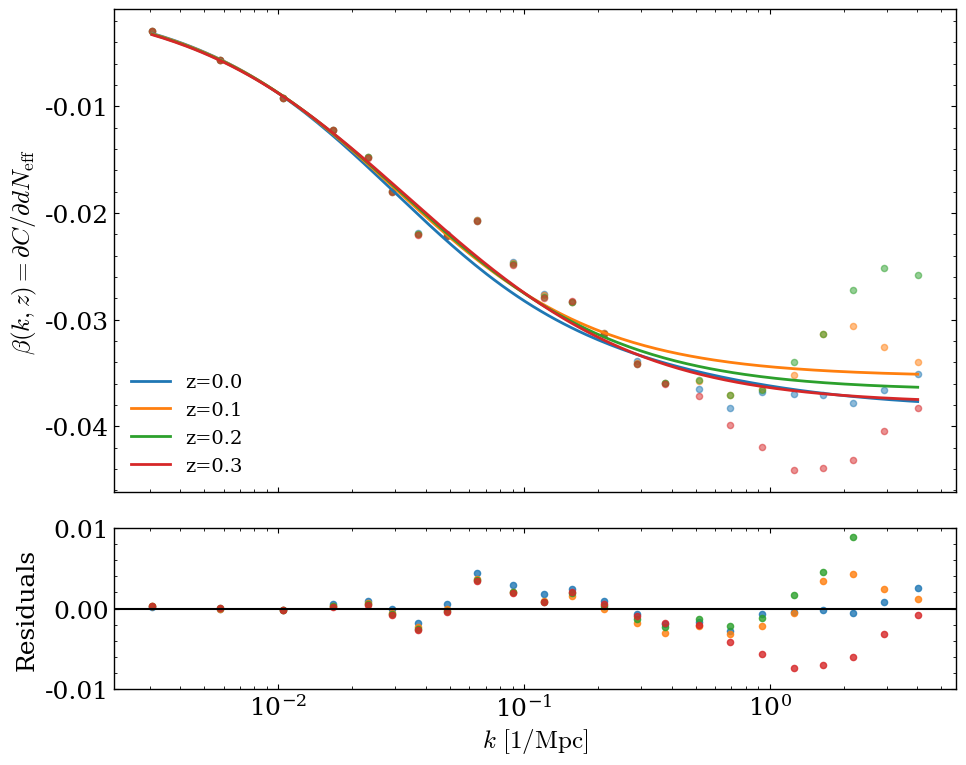

In [ ]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================

z_to_plot = [0.0, 0.1, 0.2, 0.3]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['dNeff']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['dNeff'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        resp_fit = pade_model(k_data, z, *popt_global_dNeff)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        resp_cont = pade_model(k_cont, z, *popt_global_dNeff)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial dN_{\mathrm{eff}}$')


# Clean up legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

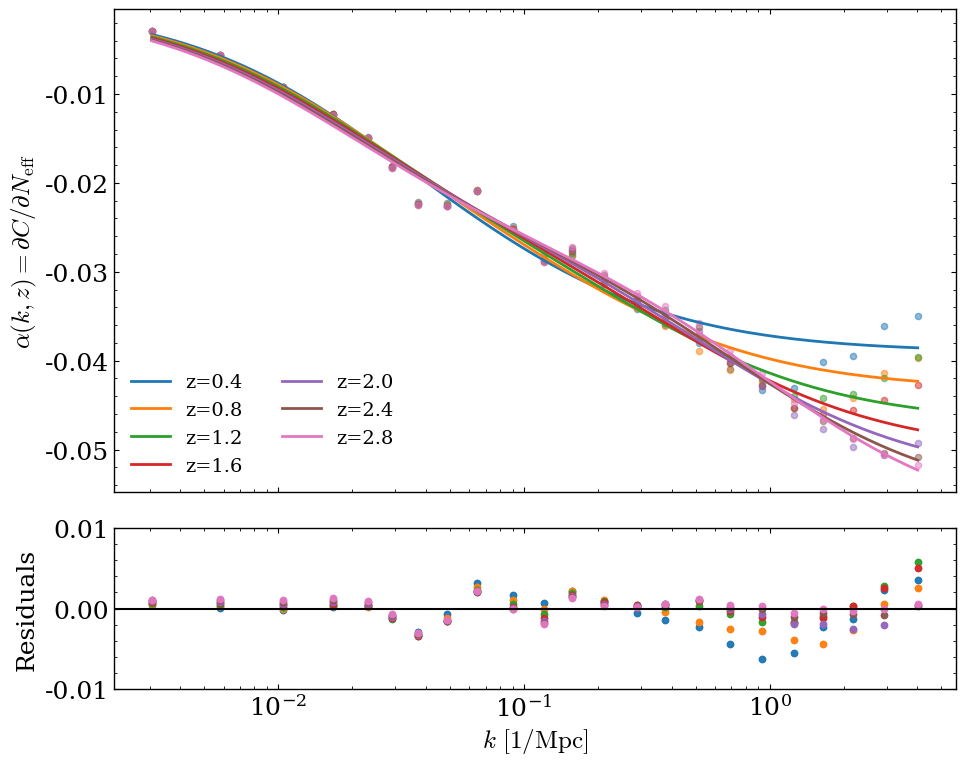

In [10]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['dNeff']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['dNeff'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        resp_fit = pade_model(k_data, z, *popt_global_dNeff)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        resp_cont = pade_model(k_cont, z, *popt_global_dNeff)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        # Note: We use (Data - Fit) because dividing by values near 0.0 will cause math errors
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
        # Plot +- 10% residual lines for reference
        # ax2.axhline(10, color='gray', lw=1, ls='--')
        # ax2.axhline(-10, color='gray', lw=1, ls='--')

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\alpha(k, z) = \partial C / \partial N_{\mathrm{eff}}$')

# Clean up legend to avoid duplicates
ax1.legend(ncols = 2, loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

In [20]:
# =================================================================
# 2. GUESSES AND BOUNDS FOR f_idm
# =================================================================
p0_guess = [
    # a1_0, a1_z, a2_0, a2_z, a3_0, a3_z
    1.0, 0.0, 1.0, 0.0, 0.8, 0.0,
    # b1_0, b1_z, b2_0, b2_z, b3_0, b3_z
    1.0, 0.0, 1.5, 0.0, 1.0, 0.0
]

# Lower bounds: Base coeffs > 0.001 to avoid poles. Exponents down to -10.
lower_bounds = [
    -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf,
      0.001, -np.inf,   0.001, -np.inf,   0.001, -np.inf
]

# Upper bounds: Give the optimizer plenty of room
upper_bounds = [
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10,
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10
]

labels_fidm = ['A0', 'gamma_A', 'B0', 'gamma_B', 'kt0', 'gamma_kt', 'alpha', 'beta']

# =================================================================
# 3. EXECUTION (WITH BOUNDS RE-ADDED)
# =================================================================
# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['fidm'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)
sigma_all = np.concatenate(sigma_all)

# -----------------------------------------------------------------
# OPTION A: The Global Fit (Recommended to try first)
# -----------------------------------------------------------------
# print("Attempting Global Fit...")
# popt_global_fidm, pcov_global_fidm = perform_fit(
#     k_all, z_all, resp_all, sigma_all, p0_guess, bounds_pade, "Global (All z)"
# )

In [55]:
# =================================================================
# 3. EXECUTION (WITH RANDOMIZED GLOBAL FIT LOOP)
# =================================================================
# Flatten the dictionary into arrays
k_all, z_all, resp_all, sigma_all = [], [], [], []
for z_val, (k_arr, resp_arr, sig_arr) in response_functions['fidm'].items():
    k_all.append(k_arr)
    resp_all.append(resp_arr)
    sigma_all.append(sig_arr)
    z_all.append(np.full_like(k_arr, z_val))

k_all = np.concatenate(k_all)
z_all = np.concatenate(z_all)
resp_all = np.concatenate(resp_all)
sigma_all = np.concatenate(sigma_all)

# --- NEW: Randomized 100 Loop Execution ---
n_runs = 100
successful_fits_fidm = []

print(f"Attempting {n_runs} randomized global fits for f_idm...")

for i in range(n_runs):
    # Generate random initial guesses (p0)
    # We want base coeffs (indices 0, 2, 4, 6, 8, 10) to be strictly positive.
    # We want z-exponents (indices 1, 3, 5, 7, 9, 11) to freely vary.
    p0_random = np.zeros(12)
    p0_random[0::2] = np.random.uniform(0.01, 500, size=6)  # Base coeffs
    p0_random[1::2] = np.random.uniform(-500, 500, size=6)   # z-exponents
    
    try:
        # Curve fit using the provided very loose bounds_pade
        popt, pcov = curve_fit(
            fit_wrapper, 
            (k_all, z_all), 
            resp_all, 
            p0=p0_random, 
            sigma=sigma_all, 
            absolute_sigma=False,
            maxfev=100000, 
            bounds=bounds_pade
        )
        
        # Calculate Sum of Squared Residuals (SSR) to score the fit
        predictions = fit_wrapper((k_all, z_all), *popt)
        residuals = resp_all - predictions
        ssr = np.sum((residuals / sigma_all)**2)
        
        successful_fits_fidm.append({
            'run': i + 1,
            'p0': p0_random,
            'popt': popt,
            'pcov': pcov,
            'ssr': ssr
        })
        # Print progress every 10 runs
        if (i + 1) % 10 == 0:
            print(f"  -> Completed {i + 1} runs, {len(successful_fits_fidm)} successful fits so far...")
        
    except RuntimeError:
        pass
    except ValueError:
        pass


# Sort the stored fits by SSR (lowest error first)
best_fits_fidm = sorted(successful_fits_fidm, key=lambda x: x['ssr'])

# Keep the top 3
top_3_fits_fidm = best_fits_fidm[:3]

print(f"\nCompleted {len(successful_fits_fidm)} successful fits out of {n_runs} attempts.")
print("\n--- TOP 3 FITS (f_idm) ---")

# Note: labels is defined in previous cell block but labels_fidm is what you defined above. 
# We'll stick to 'labels' since it's a 12-parameter Padé fit.
labels = ['a1_0', 'a1_z', 'a2_0', 'a2_z', 'a3_0', 'a3_z', 
          'b1_0', 'b1_z', 'b2_0', 'b2_z', 'b3_0', 'b3_z']

for rank, fit in enumerate(top_3_fits_fidm):
    print(f"\nRank {rank + 1} (from Run {fit['run']}) - SSR: {fit['ssr']:.4f}")
    for l, val in zip(labels, fit['popt']):
        print(f"  {l}: {val:>8.4f}")

# Assign the absolute best fit to global variables
if top_3_fits_fidm:
    popt_global_fidm = top_3_fits_fidm[0]['popt']
    pcov_global_fidm = top_3_fits_fidm[0]['pcov']
    print("\n✅ Assigned the Rank 1 fit to `popt_global_fidm`!")
else:
    print("\n❌ WARNING: No fits converged successfully.")

Attempting 100 randomized global fits for f_idm...


/tmp/ipykernel_10367/2067672176.py:12: RuntimeWarning: overflow encountered in power
  a1 = a1_0 * (u ** a1_z)
/tmp/ipykernel_10367/2067672176.py:19: RuntimeWarning: overflow encountered in power
  b3 = b3_0 * (u ** b3_z)
/tmp/ipykernel_10367/2067672176.py:24: RuntimeWarning: invalid value encountered in divide
  return num / den
/tmp/ipykernel_10367/2067672176.py:19: RuntimeWarning: overflow encountered in multiply
  b3 = b3_0 * (u ** b3_z)
/tmp/ipykernel_10367/2067672176.py:12: RuntimeWarning: overflow encountered in multiply
  a1 = a1_0 * (u ** a1_z)
/tmp/ipykernel_10367/2067672176.py:17: RuntimeWarning: overflow encountered in power
  b1 = b1_0 * (u ** b1_z)
/tmp/ipykernel_10367/2067672176.py:13: RuntimeWarning: overflow encountered in power
  a2 = a2_0 * (u ** a2_z)
/tmp/ipykernel_10367/2067672176.py:14: RuntimeWarning: overflow encountered in power
  a3 = a3_0 * (u ** a3_z)
/tmp/ipykernel_10367/2067672176.py:18: RuntimeWarning: overflow encountered in power
  b2 = b2_0 * (u ** b2

  -> Completed 10 runs, 7 successful fits so far...
  -> Completed 20 runs, 16 successful fits so far...


/tmp/ipykernel_10367/2067672176.py:17: RuntimeWarning: overflow encountered in multiply
  b1 = b1_0 * (u ** b1_z)
/tmp/ipykernel_10367/2067672176.py:14: RuntimeWarning: overflow encountered in multiply
  a3 = a3_0 * (u ** a3_z)


  -> Completed 40 runs, 31 successful fits so far...
  -> Completed 50 runs, 39 successful fits so far...
  -> Completed 60 runs, 48 successful fits so far...
  -> Completed 70 runs, 57 successful fits so far...
  -> Completed 80 runs, 66 successful fits so far...
  -> Completed 90 runs, 75 successful fits so far...

Completed 83 successful fits out of 100 attempts.

--- TOP 3 FITS (f_idm) ---

Rank 1 (from Run 10) - SSR: 0.0346
  a1_0:  12.2414
  a1_z: -80160.3352
  a2_0:  39.4951
  a2_z:  17.5683
  a3_0: -165374.3809
  a3_z:  14.2822
  b1_0: 6187.0727
  b1_z:  16.7335
  b2_0: 393189.6096
  b2_z: -657644.3145
  b3_0: 8290461.0047
  b3_z:  13.9385

Rank 2 (from Run 68) - SSR: 0.1746
  a1_0:  -0.0461
  a1_z: 488.8696
  a2_0:   6.3351
  a2_z: -156.4175
  a3_0: -716.2177
  a3_z: -60.8818
  b1_0:   2.2838
  b1_z: 488.5655
  b2_0: 613.6215
  b2_z: 393.6434
  b3_0: 31060.0186
  b3_z: -415.8769

Rank 3 (from Run 58) - SSR: 0.1807
  a1_0:  -0.1888
  a1_z: 502.6255
  a2_0: -341.6901
  a2_z: 377

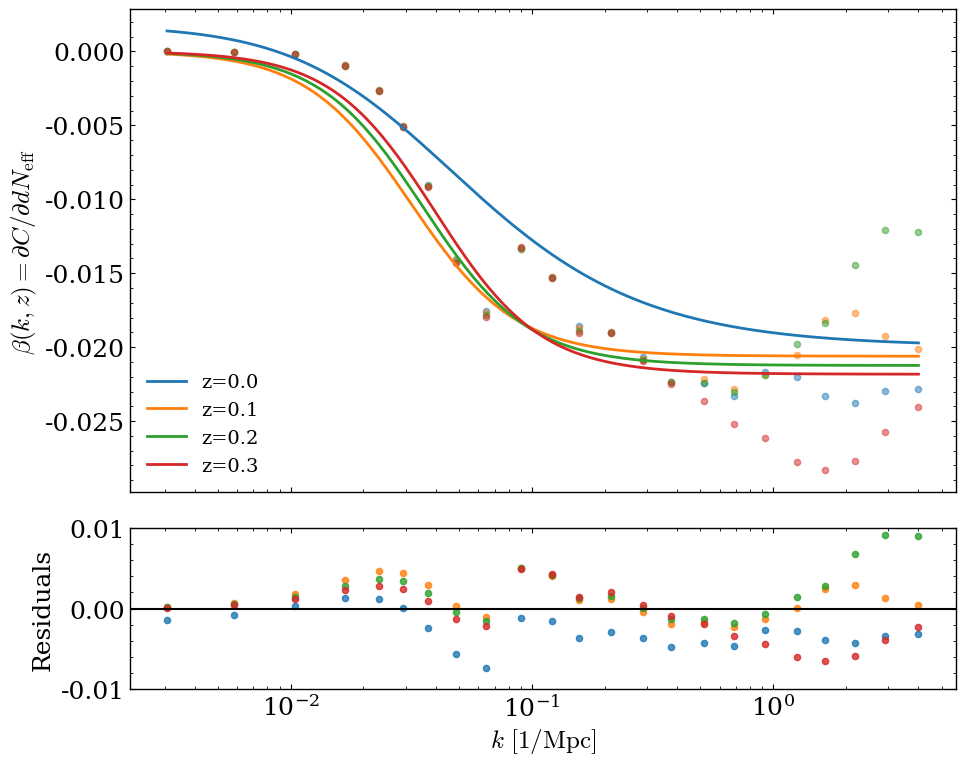

In [56]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.0, 0.1, 0.2, 0.3]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']


# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['fidm']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['fidm'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        resp_fit = pade_model(k_data, z, *popt_global_fidm)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        resp_cont = pade_model(k_cont, z, *popt_global_fidm)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial dN_{\mathrm{eff}}$')


# Clean up legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

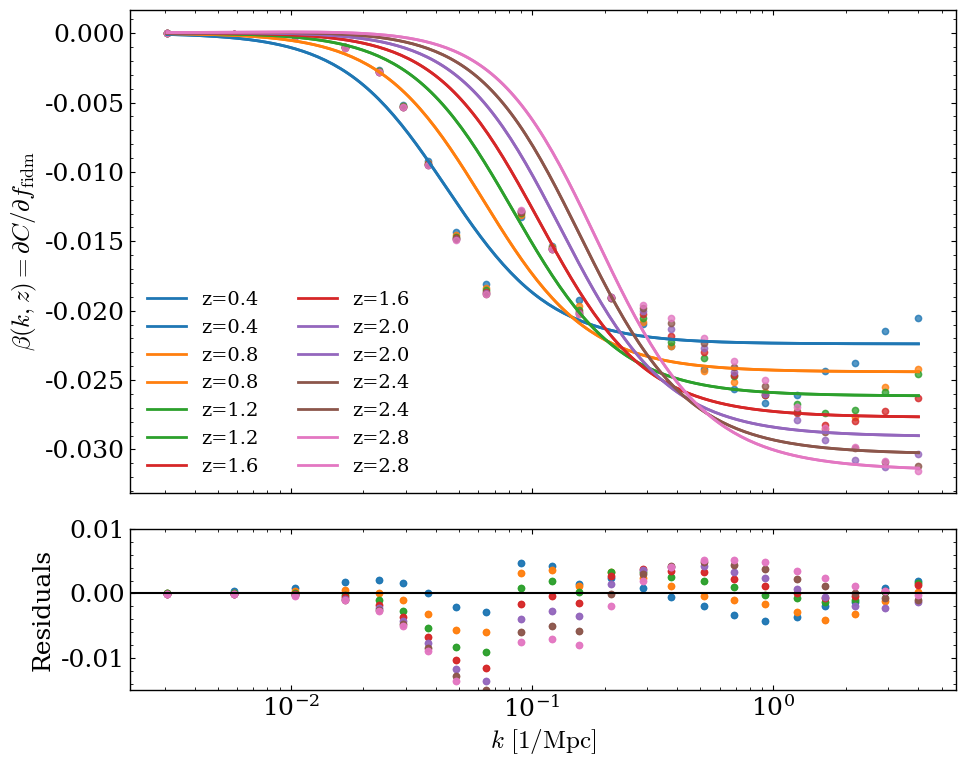

In [57]:
# =================================================================
# 3. VISUALIZE THE 2D FIT WITH RESIDUALS
# =================================================================
z_to_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']

# Set up the split plot (3:1 height ratio)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

for z, color in zip(z_to_plot, colors):
    if z in response_functions['fidm']:
        # 1. Get the Exact Data
        k_data, resp_data, sigma_data = response_functions['fidm'][z]
        
        # 2. Calculate the Analytical Fit at the exact data k-points
        resp_fit = pade_model(k_data, z, *popt_global_fidm)

        # 3. Plot Data & Continuous Line on Top Panel (ax1)
        k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
        resp_cont = pade_model(k_cont, z, *popt_global_fidm)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20, )
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
            
        ax1.scatter(k_data, resp_data, color=color, alpha=0.5, s=20)
        ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'z={z}')
        
        # 4. Plot Absolute Residuals on Bottom Panel (ax2)
        # Note: We use (Data - Fit) because dividing by values near 0.0 will cause math errors
        resid = (resp_data - resp_fit)
        ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)
        # Plot +- 10% residual lines for reference
        # ax2.axhline(10, color='gray', lw=1, ls='--')
        # ax2.axhline(-10, color='gray', lw=1, ls='--')

# --- Top Panel Formatting ---
ax1.set_xscale('log')
ax1.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{fidm}}$')

# Clean up legend to avoid duplicates
ax1.legend(ncols = 2, loc = 'lower left')

# --- Bottom Panel Formatting ---
ax2.axhline(0, color='black', lw=1.5, ls='-')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.set_ylabel('Residuals')

# Optional: You can set y-limits on the residuals to zoom in, 
# e.g., if you want to bound them to +/- 0.05 absolute error
ax2.set_ylim(-0.015, 0.01)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10367/2691290709.py:3: RuntimeWarning: invalid value encountered in divide
  corr_matrix_dNeff = pcov_global_dNeff / np.outer(perr_dNeff, perr_dNeff)


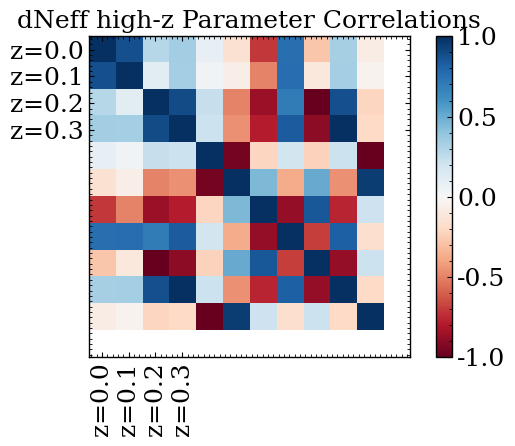

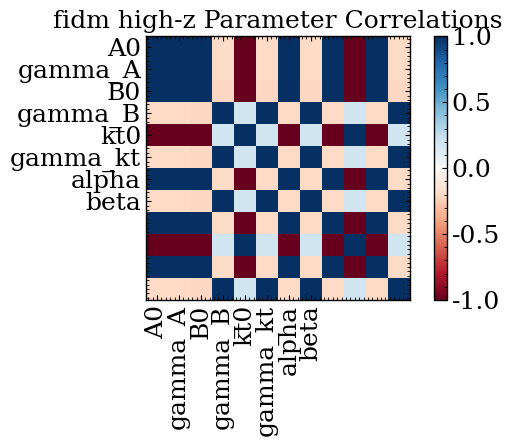

In [58]:
# dNeff high-z correlation matrix
perr_dNeff = np.sqrt(np.diag(pcov_global_dNeff))
corr_matrix_dNeff = pcov_global_dNeff / np.outer(perr_dNeff, perr_dNeff)
plt.imshow(corr_matrix_dNeff, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("dNeff high-z Parameter Correlations")
plt.tight_layout()
plt.show()


# fidm high-z correlation matrix
perr_fidm = np.sqrt(np.diag(pcov_global_fidm))
corr_matrix_fidm = pcov_global_fidm / np.outer(perr_fidm, perr_fidm)
plt.imshow(corr_matrix_fidm, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels_fidm)), labels_fidm, rotation=90)
plt.yticks(range(len(labels_fidm)), labels_fidm)
plt.title("fidm high-z Parameter Correlations")
plt.tight_layout()
plt.show()

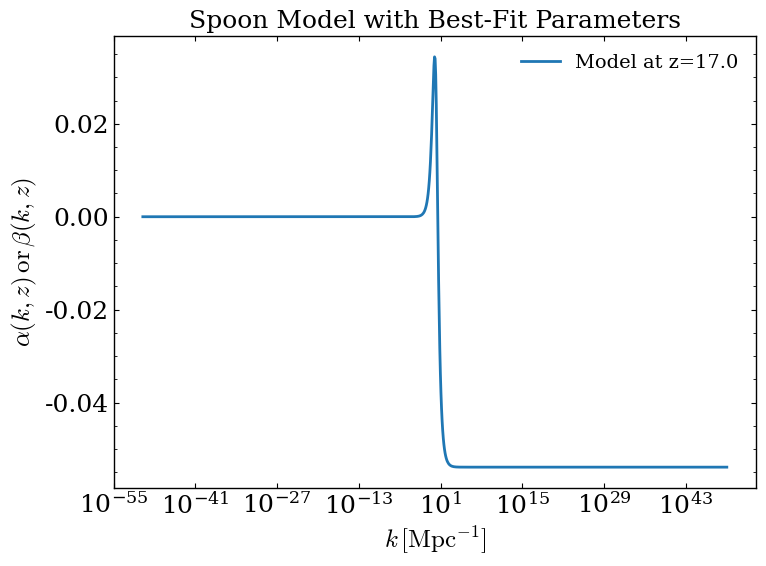

In [60]:
def test_response(target_param, k, z):
    if target_param == 'dNeff':
        response_test = pade_model(k, z, *popt_global_dNeff)
    elif target_param == 'fidm':
        response_test = pade_model(k, z, *popt_global_fidm)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.semilogx(k, response_test, label=f'Model at z={z}')
    ax.set_xscale('log')
    ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$\alpha(k,z)\,\mathrm{or}\,\beta(k, z)$')
    ax.set_title('Spoon Model with Best-Fit Parameters')
    ax.legend()
    plt.tight_layout()
    plt.show()

k_test = np.logspace(-50, 50, 1000)

test_response('fidm', k_test, 17.0)

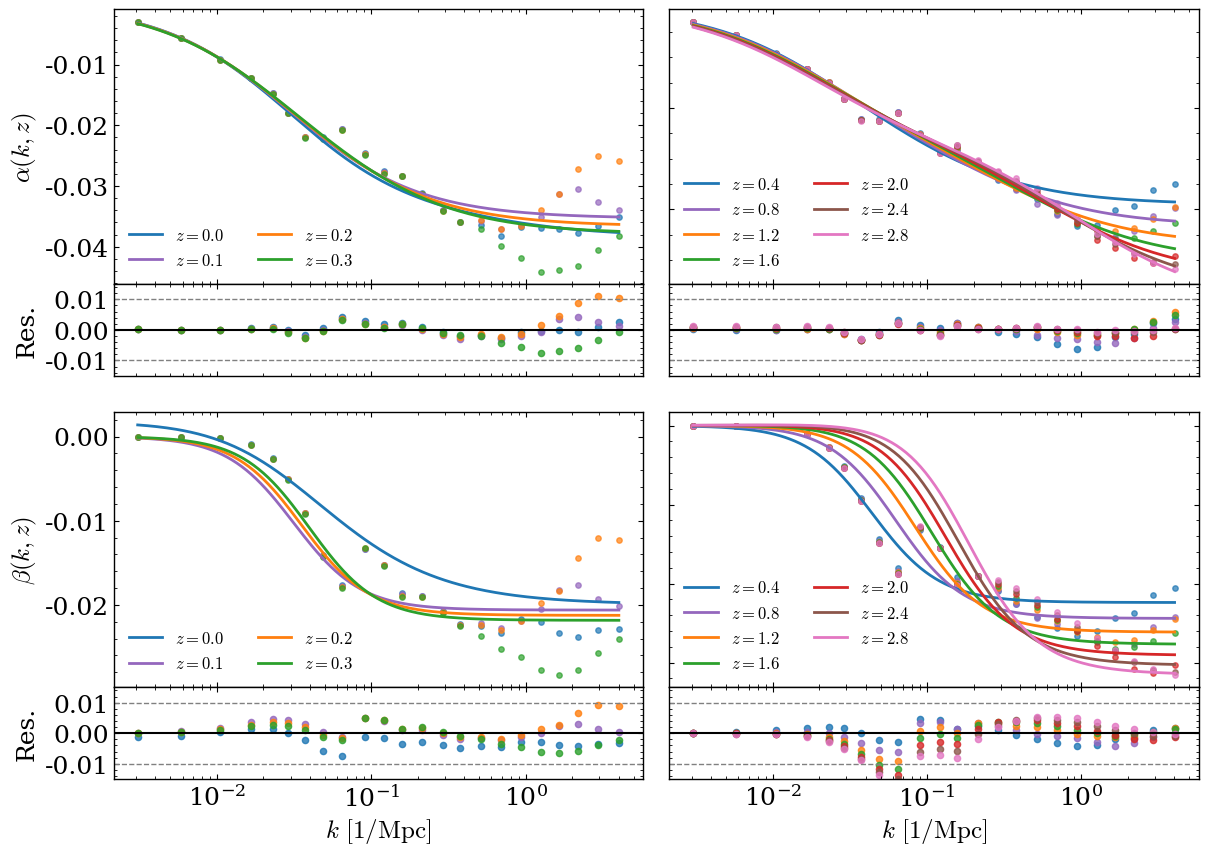

In [62]:
# --- Alpha (dNeff) Params ---
alpha_params_dict = {
    'a1_0': popt_global_dNeff[0],
    'a1_z': popt_global_dNeff[1],
    'a2_0': popt_global_dNeff[2],
    'a2_z': popt_global_dNeff[3],
    'a3_0': popt_global_dNeff[4],
    'a3_z': popt_global_dNeff[5],
    'b1_0': popt_global_dNeff[6],
    'b1_z': popt_global_dNeff[7],
    'b2_0': popt_global_dNeff[8],
    'b2_z': popt_global_dNeff[9],
    'b3_0': popt_global_dNeff[10],
    'b3_z': popt_global_dNeff[11]
}

# --- Beta (fidm) Params ---
beta_params_dict = {
    'a1_0': popt_global_fidm[0],
    'a1_z': popt_global_fidm[1],
    'a2_0': popt_global_fidm[2],
    'a2_z': popt_global_fidm[3],
    'a3_0': popt_global_fidm[4],
    'a3_z': popt_global_fidm[5],
    'b1_0': popt_global_fidm[6],
    'b1_z': popt_global_fidm[7],
    'b2_0': popt_global_fidm[8],
    'b2_z': popt_global_fidm[9],
    'b3_0': popt_global_fidm[10],
    'b3_z': popt_global_fidm[11]
}

# 1. Define the parameters for the grid
z_low_plot = [0.0, 0.1, 0.2, 0.3]   # Replace with your actual low-z values to plot
z_high_plot = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8]  # Replace with your actual high-z values to plot

# Define the 4 panels we want to create
panels = [
    {
        'param': 'dNeff', 'regime': 'low', 'z_list': z_low_plot, 
        'title': r'$\alpha(k, z)$ (Response to $\Delta N_{\rm eff}$) - Low $z$',
        'ylabel': r'$\alpha(k, z)$',
        'fit_func': pade_model, # Assuming this is your low-z function name
        'fit_params': alpha_params_dict
    },
    {
        'param': 'dNeff', 'regime': 'high', 'z_list': z_high_plot, 
        'title': r'$\alpha(k, z)$ (Response to $\Delta N_{\rm eff}$) - High $z$',
        'ylabel': r'$\alpha(k, z)$',
        'fit_func': pade_model,   # Your high-z function
        'fit_params': alpha_params_dict
    },
    {
        'param': 'fidm', 'regime': 'low', 'z_list': z_low_plot, 
        'title': r'$\beta(k, z)$ (Response to $f_{\rm idm}$) - Low $z$',
        'ylabel': r'$\beta(k, z)$',
        'fit_func': pade_model,
        'fit_params': beta_params_dict
    },
    {
        'param': 'fidm', 'regime': 'high', 'z_list': z_high_plot, 
        'title': r'$\beta(k, z)$ (Response to $f_{\rm idm}$) - High $z$',
        'ylabel': r'$\beta(k, z)$',
        'fit_func': pade_model,
        'fit_params': beta_params_dict
    }
]

# Set up outer figure (matching proportion and reducing hspace for shared x-axis)
fig = plt.figure(figsize=(14, 10))
outer_gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.05, hspace=0.10)

# Use a nice color map for the z-values
colors = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown', 'tab:pink', 'tab:gray']

# Loop through the 4 panels
for i, panel in enumerate(panels):
    # Determine position in the 2x2 grid
    row, col = divmod(i, 2)
    
    # Create inner GridSpec for main plot + residuals (Height ratio 3:1)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row, col], 
                                                height_ratios=[3, 1], hspace=0.0)
    
    ax1 = fig.add_subplot(inner_gs[0])
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    target_param = panel['param']
    func = panel['fit_func']
    popt = panel['fit_params']
    
    for z, color in zip(panel['z_list'], colors):
        if z in response_functions[target_param]:
            # 1. Get the Exact Data
            k_data, resp_data, sigma_data = response_functions[target_param][z]
            
            # 2. Calculate Analytical Fit 
            resp_fit = func(k_data, z, **popt)
            
            # 3. Plot Data & Continuous Line
            k_cont = np.logspace(np.log10(k_data.min()), np.log10(k_data.max()), 200)
            resp_cont = func(k_cont, z, **popt)
            
            # Updated to match plot 1 marker style and label math formatting
            ax1.scatter(k_data, resp_data, color=color, alpha=0.7, s=15)
            ax1.plot(k_cont, resp_cont, color=color, lw=2, ls='-', label=f'$z={z}$')
            
            # 4. Plot Absolute Residuals 
            with np.errstate(divide='ignore', invalid='ignore'):
                resid = (resp_data - resp_fit)
                
            ax2.scatter(k_data, resid, color=color, s=20, alpha=0.8)

    # --- Formatting Top Panel (ax1) ---
    ax1.set_xscale('log')
    
    if col == 0:
        ax1.set_ylabel(panel['ylabel'])
    else:
        plt.setp(ax1.get_yticklabels(), visible=False)
        
    plt.setp(ax1.get_xticklabels(), visible=False) 
    
    # Clean legend matching plot 1
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='lower left', ncol=2, fontsize=12)

    # --- Formatting Bottom Panel (ax2) ---
    ax2.axhline(0, color='black', lw=1.5, ls='-')
    ax2.axhline(0.01, color='gray', lw=1, ls='--')  # Changed from 10 to 0.01 to fit ylim
    ax2.axhline(-0.01, color='gray', lw=1, ls='--') # Changed from -10 to -0.01 to fit ylim
    
    # Left-axis label logic
    if col == 0:
        ax2.set_ylabel('Res.')
    else:
        plt.setp(ax2.get_yticklabels(), visible=False)
        
    ax2.set_ylim(-0.015, 0.015) 
    
    # Shared X-axis logic (Only bottom row gets x-labels and ticks)
    if row == 1:
        ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    else:
        plt.setp(ax2.get_xticklabels(), visible=False)

# plt.savefig('alpha_beta_fits_pade.pdf', bbox_inches='tight')
plt.show()